In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -q kaggle transformers timm matplotlib opencv-python


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.5 MB/s eta 0:00:00


In [ ]:
# Upload kaggle.json manually
from google.colab import files
files.upload()

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download & unzip this new dataset (replace with correct dataset slug)
!kaggle datasets download -d zaidpy/oral-cancer-dataset
!unzip -q oral-cancer-dataset.zip -d dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zaidpy/oral-cancer-dataset
License(s): apache-2.0
 90% 284M/315M [00:00<00:00, 371MB/s]
100% 315M/315M [00:00<00:00, 422MB/s]


In [ ]:
from glob import glob
import os, shutil

os.makedirs('data/train/CANCER', exist_ok=True)
os.makedirs('data/train/NON CANCER', exist_ok=True)

# Copy from new dataset path (exact from screenshot)
cancer_imgs = glob('dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/*.jpeg')
non_cancer_imgs = glob('dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/NON CANCER/*.jpeg')

for img in cancer_imgs:
    shutil.copy(img, 'data/train/CANCER')
for img in non_cancer_imgs:
    shutil.copy(img, 'data/train/NON CANCER')


In [ ]:
from PIL import Image, UnidentifiedImageError
import cv2
import os

def remove_all_corrupt_images(folder_path):
    removed = 0
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_path):
            continue

        for file_name in os.listdir(cls_path):
            file_path = os.path.join(cls_path, file_name)
            try:
                # First try with OpenCV
                img = cv2.imread(file_path)
                if img is None:
                    raise ValueError("Unreadable by OpenCV")

                # Then check with PIL (some broken headers are only caught here)
                with Image.open(file_path) as img_pil:
                    img_pil.verify()

            except Exception as e:
                print(f"❌ Removing unreadable image: {file_path}")
                os.remove(file_path)
                removed += 1

    print(f"\n✅ Fully cleaned. {removed} corrupted images removed.")

# Run this on your dataset
remove_all_corrupt_images("data/train")


❌ Removing unreadable image: data/train/CANCER/407.jpeg
❌ Removing unreadable image: data/train/CANCER/455.jpeg
❌ Removing unreadable image: data/train/CANCER/101.jpeg
❌ Removing unreadable image: data/train/CANCER/328.jpeg
❌ Removing unreadable image: data/train/CANCER/485.jpeg
❌ Removing unreadable image: data/train/CANCER/317.jpeg
❌ Removing unreadable image: data/train/CANCER/450.jpeg
❌ Removing unreadable image: data/train/CANCER/200.jpeg
❌ Removing unreadable image: data/train/CANCER/273.jpeg
❌ Removing unreadable image: data/train/CANCER/481.jpeg

✅ Fully cleaned. 10 corrupted images removed.


In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = ImageFolder("data/train", transform=transform)
class_names = dataset.classes

# Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=dataset.targets, random_state=42)

train_ds = Subset(dataset, train_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)


In [ ]:
from transformers import SwinForImageClassification
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=2,
    ignore_mismatched_sizes=True  # Important fix
)

model.to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_acc_list, train_loss_list = [], []

for epoch in range(20):
    model.train()
    total_loss, correct = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(train_ds)
    train_loss_list.append(total_loss)
    train_acc_list.append(acc)
    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={acc:.4f}")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1: Loss=1.0745, Accuracy=0.9907


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2: Loss=0.2092, Accuracy=1.0000


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 18: Loss=0.2754, Accuracy=0.9973


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 19: Loss=0.0688, Accuracy=1.0000


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 20: Loss=0.0495, Accuracy=1.0000


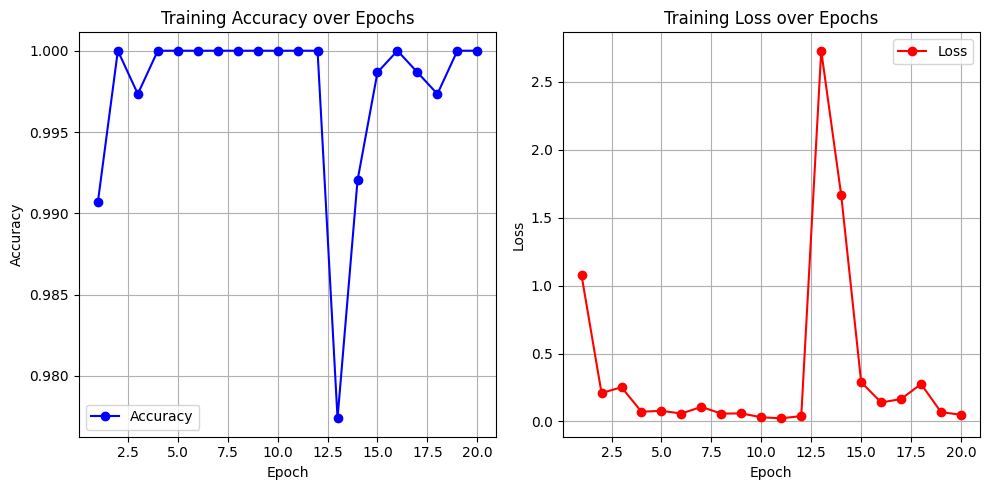

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_list) + 1)

plt.figure(figsize=(10, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_list, 'bo-', label='Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_list, 'ro-', label='Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_plot.png", dpi=300)  # 🔽 Save for research paper
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch

# Evaluate model
model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).logits
        probs = outputs.softmax(dim=1).cpu().numpy()

        y_score.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())



📄 Classification Report:
              precision    recall  f1-score   support

      CANCER       0.97      0.92      0.94        98
  NON CANCER       0.92      0.97      0.94        90

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



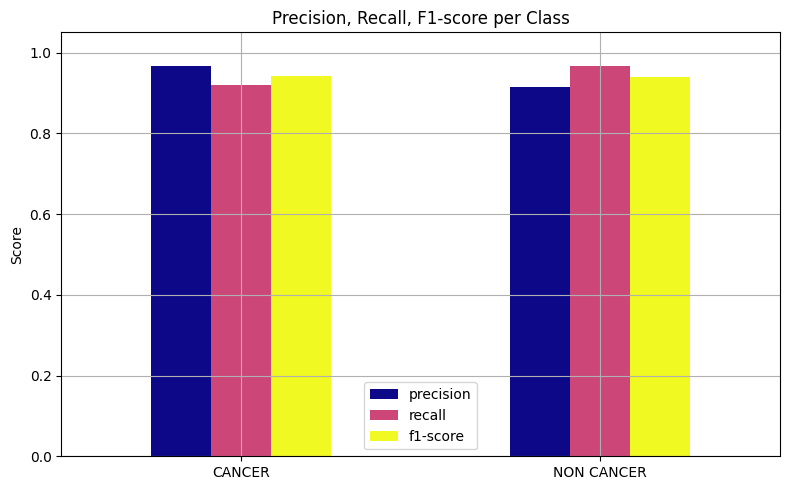

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Print text report
report = classification_report(y_true, y_pred, target_names=dataset.classes, output_dict=True)
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

# Save Bar Chart for Paper
df = pd.DataFrame(report).transpose().iloc[:2][['precision', 'recall', 'f1-score']]
df.plot(kind='bar', figsize=(8, 5), colormap='plasma', rot=0)
plt.title("Precision, Recall, F1-score per Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.savefig("classification_report_bar.png", dpi=300)
plt.show()


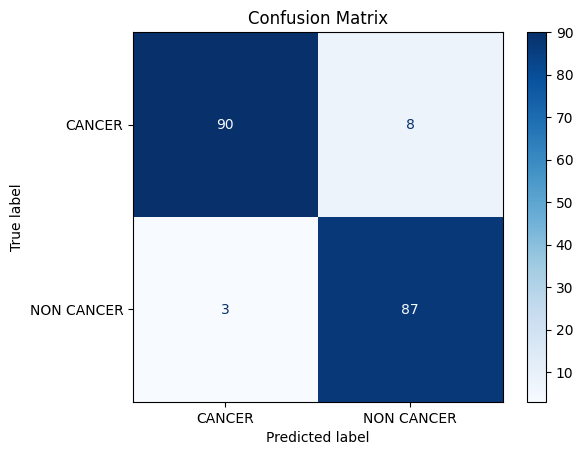

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


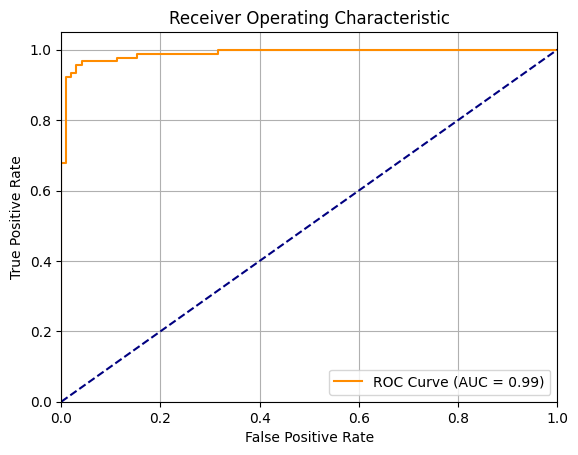

In [ ]:
# Binarize true labels
y_true_bin = label_binarize(y_true, classes=[0, 1])
y_score = np.array(y_score)

fpr, tpr, _ = roc_curve(y_true_bin, y_score[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("roc_curve.png", dpi=300)
plt.show()


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/oral_cancer_swin_new.pth")
print("✅ Model saved to Drive.")


✅ Model saved to Drive.


In [ ]:
from transformers import SwinForImageClassification
import torch

# Load model
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load("/content/drive/MyDrive/oral_cancer_swin_new.pth", map_location=torch.device('cpu')))
model.eval()


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

Saving images (3).jpg to images (3).jpg


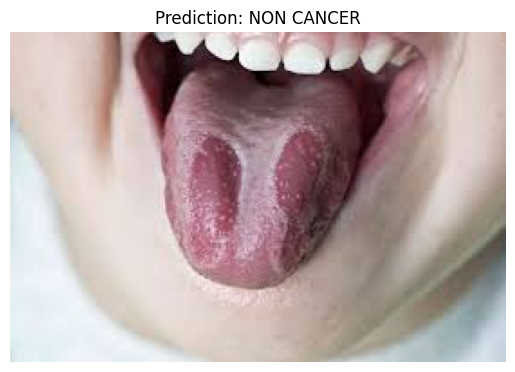

In [ ]:
from google.colab import files
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
filename = next(iter(uploaded))

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load and preprocess image
img = Image.open(filename).convert("RGB")
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Predict
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output.logits, dim=1).item()

# Class names from your training dataset
class_names = ["CANCER", "NON CANCER"]

# Display
plt.imshow(img)
plt.title(f"Prediction: {class_names[pred]}")
plt.axis("off")
plt.show()
